# 📦 Análisis de Modelos de Regresión Lineal
## Dólar · Energía · Glucosa
---
Este notebook carga tres modelos preentrenados (`.pkl`) de regresión lineal y permite:
- Inspeccionar coeficientes e interceptos
- Realizar predicciones interactivas
- Visualizar la recta de regresión por variable
- Comparar los tres modelos

**Archivos requeridos:** `modelo_dolar.pkl` · `modelo_energia.pkl` · `modelo_glucosa.pkl`

---


## 1. Importar bibliotecas y cargar modelos

In [18]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✅ Bibliotecas cargadas")


✅ Bibliotecas cargadas


In [19]:
# ── Cargar los tres modelos ───────────────────────────────────────────────
with open('modelo_dolar.pkl',   'rb') as f: modelo_dolar   = pickle.load(f)
with open('modelo_energia.pkl', 'rb') as f: modelo_energia = pickle.load(f)
with open('modelo_glucosa.pkl', 'rb') as f: modelo_glucosa = pickle.load(f)

modelos = {
    'Dólar':   modelo_dolar,
    'Energía': modelo_energia,
    'Glucosa': modelo_glucosa,
}

print("✅ Modelos cargados exitosamente")
for nombre, m in modelos.items():
    print(f"   {nombre:8s} → features: {list(m.feature_names_in_)}")


✅ Modelos cargados exitosamente
   Dólar    → features: ['Dia', 'Inflacion', 'Tasa_interes']
   Energía  → features: ['Temperatura', 'Hora', 'Dia_Semana']
   Glucosa  → features: ['Edad', 'IMC', 'Actividad_Fisica']


---
## 2. Inspección de los modelos

In [20]:
# Resumen de coeficientes e interceptos
print("=" * 65)
print(f"  {'MODELO':<10} {'VARIABLE':<20} {'COEFICIENTE':>14}  {'INTERCEPTO':>12}")
print("=" * 65)

for nombre, m in modelos.items():
    for i, (feat, coef) in enumerate(zip(m.feature_names_in_, m.coef_)):
        intercept_str = f"{m.intercept_:>12.4f}" if i == 0 else ""
        print(f"  {nombre if i==0 else '':<10} {feat:<20} {coef:>14.4f}  {intercept_str}")
    print("-" * 65)


  MODELO     VARIABLE                COEFICIENTE    INTERCEPTO
  Dólar      Dia                          4.9979     3981.5309
             Inflacion                 -572.6503  
             Tasa_interes                -2.2239  
-----------------------------------------------------------------
  Energía    Temperatura                  9.9249      102.7523
             Hora                         4.9700  
             Dia_Semana                  -3.0233  
-----------------------------------------------------------------
  Glucosa    Edad                         1.2193       67.7380
             IMC                          0.8689  
             Actividad_Fisica            -2.0908  
-----------------------------------------------------------------


In [21]:
# Tabla comparativa con pandas
filas = []
for nombre, m in modelos.items():
    for feat, coef in zip(m.feature_names_in_, m.coef_):
        filas.append({
            'Modelo':       nombre,
            'Variable':     feat,
            'Coeficiente':  round(coef, 4),
            'Intercepto':   round(m.intercept_, 4),
        })

df_resumen = pd.DataFrame(filas)
df_resumen


,Modelo,Variable,Coeficiente,Intercepto
0,Dólar,Dia,4.9979,3981.5309
1,Dólar,Inflacion,-572.6503,3981.5309
2,Dólar,Tasa_interes,-2.2239,3981.5309
3,Energía,Temperatura,9.9249,102.7523
4,Energía,Hora,4.9700,102.7523
5,Energía,Dia_Semana,-3.0233,102.7523
6,Glucosa,Edad,1.2193,67.7380
7,Glucosa,IMC,0.8689,67.7380
8,Glucosa,Actividad_Fisica,-2.0908,67.7380


---
## 3. Visualización de coeficientes

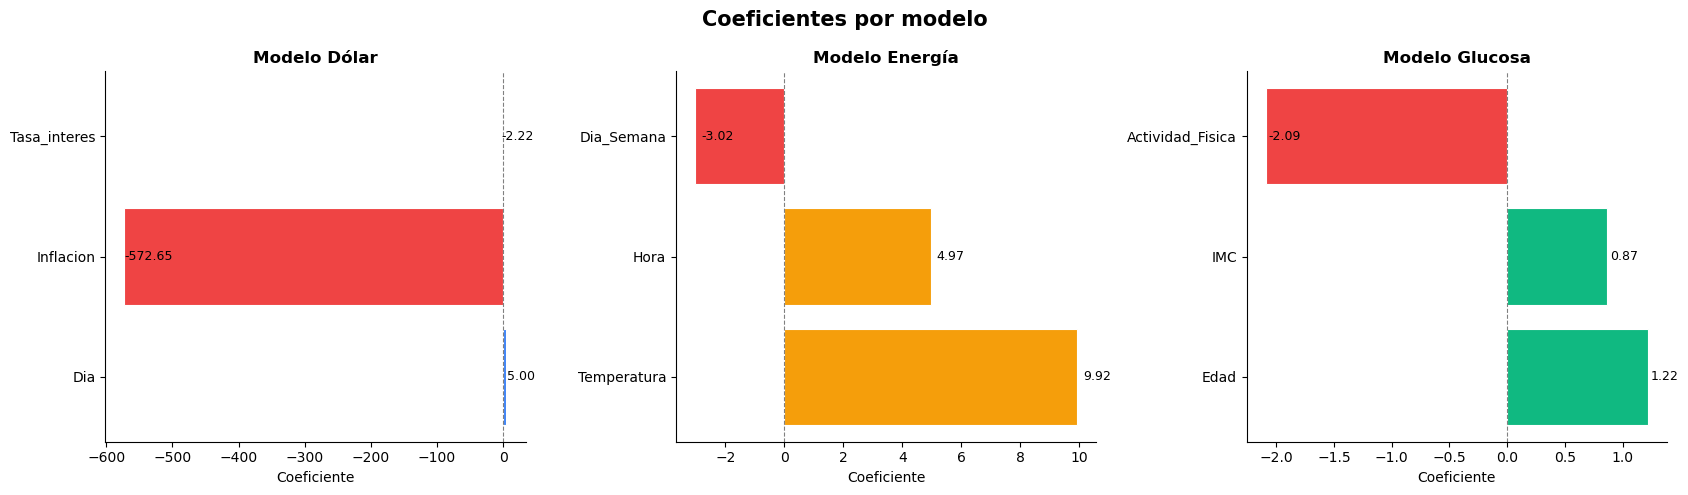

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Coeficientes por modelo', fontsize=15, fontweight='bold')

colores = {'Dólar': '#3b82f6', 'Energía': '#f59e0b', 'Glucosa': '#10b981'}

for ax, (nombre, m) in zip(axes, modelos.items()):
    feats = list(m.feature_names_in_)
    coefs = list(m.coef_)
    bar_colors = [colores[nombre] if c >= 0 else '#ef4444' for c in coefs]
    bars = ax.barh(feats, coefs, color=bar_colors, edgecolor='white', linewidth=0.8)
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(f'Modelo {nombre}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Coeficiente')
    for bar, val in zip(bars, coefs):
        ax.text(val + (max(coefs)*0.02), bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 4. Modelo Dólar
**Variables:** `Dia`, `Inflacion`, `Tasa_interes`  
**Fórmula:** `Dólar = 3981.53 + 4.998·Dia − 572.65·Inflacion − 2.224·Tasa_interes`

In [23]:
# Predicción individual — Modelo Dólar
dia          = 15       # día del mes
inflacion    = 5.2      # % inflación
tasa_interes = 8.5      # % tasa de interés

entrada = pd.DataFrame([[dia, inflacion, tasa_interes]],
                       columns=modelo_dolar.feature_names_in_)
pred = modelo_dolar.predict(entrada)[0]
print(f"Entrada:    Dia={dia}, Inflacion={inflacion}%, Tasa={tasa_interes}%")
print(f"Predicción: ${pred:,.2f} COP")


Entrada:    Dia=15, Inflacion=5.2%, Tasa=8.5%
Predicción: $1,059.82 COP


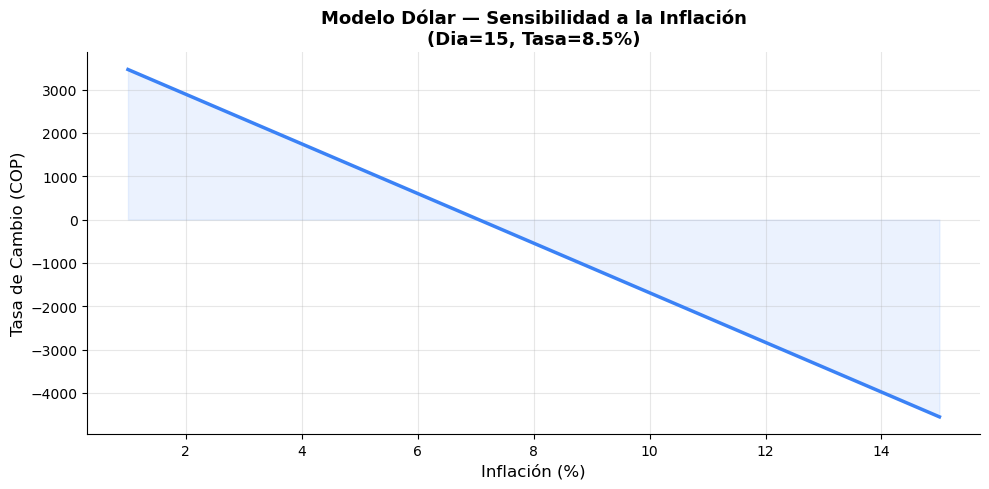

In [24]:
# Sensibilidad: cómo varía el dólar según la inflación
inflacion_range = np.linspace(1, 15, 100)
dias_fijo  = 15
tasa_fija  = 8.5

X_sim = pd.DataFrame({
    'Dia':          [dias_fijo]  * 100,
    'Inflacion':    inflacion_range,
    'Tasa_interes': [tasa_fija]  * 100,
})
preds_dolar = modelo_dolar.predict(X_sim)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(inflacion_range, preds_dolar, color='#3b82f6', linewidth=2.5)
ax.fill_between(inflacion_range, preds_dolar, alpha=0.1, color='#3b82f6')
ax.set_xlabel('Inflación (%)', fontsize=12)
ax.set_ylabel('Tasa de Cambio (COP)', fontsize=12)
ax.set_title('Modelo Dólar — Sensibilidad a la Inflación\n(Dia=15, Tasa=8.5%)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dolar_inflacion.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
# Predicciones en lote — Dólar
escenarios_dolar = pd.DataFrame({
    'Dia':          [1,  10, 20, 30,  1,  15],
    'Inflacion':    [3,   5,  7,  9, 12,   5],
    'Tasa_interes': [7,   8,  9, 10,  6,  12],
})
escenarios_dolar['Prediccion_Dolar'] = modelo_dolar.predict(escenarios_dolar).round(2)
print("Predicciones por escenario — Modelo Dólar:")
escenarios_dolar


Predicciones por escenario — Modelo Dólar:


,Dia,Inflacion,Tasa_interes,Prediccion_Dolar
0,1,3,7,2253.01
1,10,5,8,1150.47
2,20,7,9,52.92
3,30,9,10,-1044.62
4,1,12,6,-2898.62
5,15,5,12,1166.56


---
## 5. Modelo Energía
**Variables:** `Temperatura`, `Hora`, `Dia_Semana`  
**Fórmula:** `Energía = 102.75 + 9.925·Temperatura + 4.970·Hora − 3.023·Dia_Semana`

In [26]:
# Predicción individual — Modelo Energía
temperatura = 28.0   # °C
hora        = 14     # hora del día (0-23)
dia_semana  = 2      # 0=lunes ... 6=domingo

entrada_e = pd.DataFrame([[temperatura, hora, dia_semana]],
                          columns=modelo_energia.feature_names_in_)
pred_e = modelo_energia.predict(entrada_e)[0]
print(f"Entrada:    Temperatura={temperatura}°C, Hora={hora}:00, Dia_Semana={dia_semana}")
print(f"Predicción: {pred_e:.2f} kWh")


Entrada:    Temperatura=28.0°C, Hora=14:00, Dia_Semana=2
Predicción: 444.18 kWh


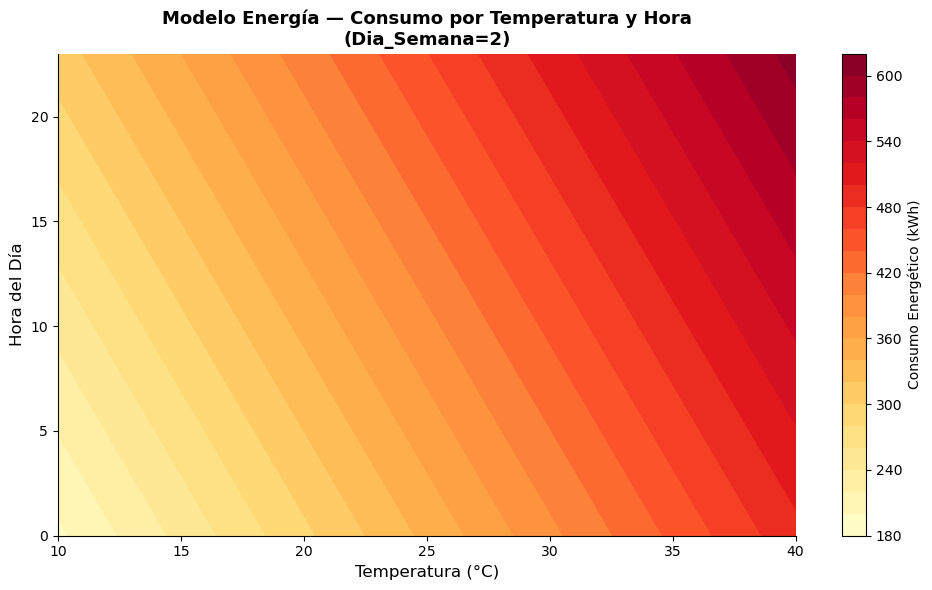

In [27]:
# Mapa de calor: Energía según Temperatura x Hora
temps  = np.linspace(10, 40, 50)
horas  = np.linspace(0, 23, 50)
T, H   = np.meshgrid(temps, horas)
dia_fijo = 2

X_grid = pd.DataFrame({
    'Temperatura': T.ravel(),
    'Hora':        H.ravel(),
    'Dia_Semana':  [dia_fijo] * T.size,
})
Z = modelo_energia.predict(X_grid).reshape(T.shape)

fig, ax = plt.subplots(figsize=(10, 6))
hm = ax.contourf(T, H, Z, levels=20, cmap='YlOrRd')
plt.colorbar(hm, ax=ax, label='Consumo Energético (kWh)')
ax.set_xlabel('Temperatura (°C)', fontsize=12)
ax.set_ylabel('Hora del Día', fontsize=12)
ax.set_title('Modelo Energía — Consumo por Temperatura y Hora\n(Dia_Semana=2)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('energia_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [28]:
# Predicciones en lote — Energía
escenarios_energia = pd.DataFrame({
    'Temperatura': [15, 20, 25, 30, 35, 38],
    'Hora':        [ 8, 12, 14, 18, 20, 22],
    'Dia_Semana':  [ 0,  1,  3,  5,  6,  0],
})
escenarios_energia['Prediccion_kWh'] = modelo_energia.predict(escenarios_energia).round(2)
print("Predicciones por escenario — Modelo Energía:")
escenarios_energia


Predicciones por escenario — Modelo Energía:


,Temperatura,Hora,Dia_Semana,Prediccion_kWh
0,15,8,0,291.39
1,20,12,1,357.87
2,25,14,3,411.39
3,30,18,5,474.84
4,35,20,6,531.38
5,38,22,0,589.24


---
## 6. Modelo Glucosa
**Variables:** `Edad`, `IMC`, `Actividad_Fisica`  
**Fórmula:** `Glucosa = 67.74 + 1.219·Edad + 0.869·IMC − 2.091·Actividad_Fisica`

In [29]:
# Predicción individual — Modelo Glucosa
edad             = 45     # años
imc              = 27.5   # kg/m²
actividad_fisica = 3      # horas/semana

entrada_g = pd.DataFrame([[edad, imc, actividad_fisica]],
                          columns=modelo_glucosa.feature_names_in_)
pred_g = modelo_glucosa.predict(entrada_g)[0]
print(f"Entrada:    Edad={edad} años, IMC={imc}, Actividad={actividad_fisica} h/sem")
print(f"Predicción: {pred_g:.2f} mg/dL")

if pred_g < 100:
    estado = "✅ Normal"
elif pred_g < 126:
    estado = "⚠️  Prediabetes"
else:
    estado = "🔴 Diabetes (referencia clínica)"
print(f"Referencia: {estado}")


Entrada:    Edad=45 años, IMC=27.5, Actividad=3 h/sem
Predicción: 140.23 mg/dL
Referencia: 🔴 Diabetes (referencia clínica)


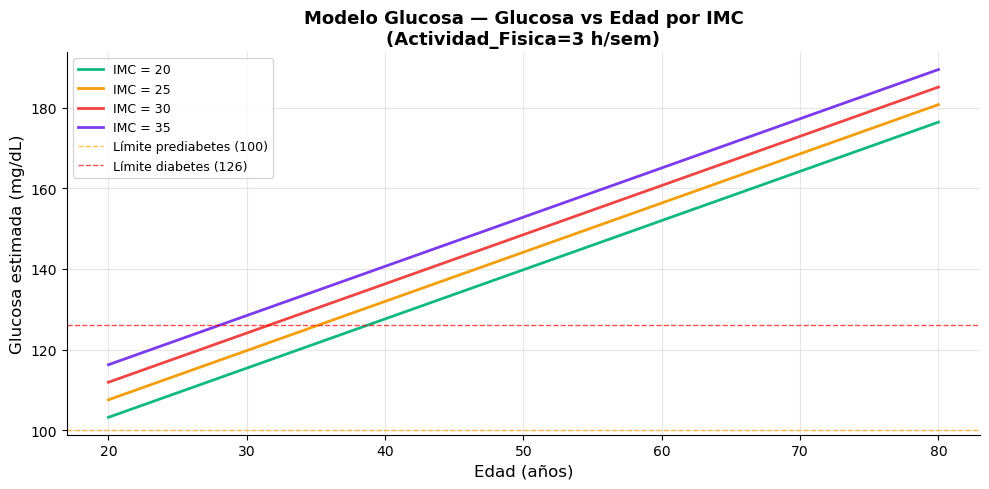

In [30]:
# Sensibilidad: glucosa según edad e IMC
edades  = np.linspace(20, 80, 60)
imc_vals = [20, 25, 30, 35]
act_fija = 3

fig, ax = plt.subplots(figsize=(10, 5))
colores_g = ['#10b981', '#f59e0b', '#ef4444', '#7c3aed']

for imc_val, color in zip(imc_vals, colores_g):
    X_g = pd.DataFrame({
        'Edad':             edades,
        'IMC':              [imc_val] * len(edades),
        'Actividad_Fisica': [act_fija] * len(edades),
    })
    preds_g = modelo_glucosa.predict(X_g)
    ax.plot(edades, preds_g, color=color, linewidth=2, label=f'IMC = {imc_val}')

ax.axhline(100, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Límite prediabetes (100)')
ax.axhline(126, color='red',    linestyle='--', linewidth=1, alpha=0.7, label='Límite diabetes (126)')
ax.set_xlabel('Edad (años)', fontsize=12)
ax.set_ylabel('Glucosa estimada (mg/dL)', fontsize=12)
ax.set_title('Modelo Glucosa — Glucosa vs Edad por IMC\n(Actividad_Fisica=3 h/sem)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('glucosa_edad_imc.png', dpi=150, bbox_inches='tight')
plt.show()


In [31]:
# Predicciones en lote — Glucosa
escenarios_glucosa = pd.DataFrame({
    'Edad':             [25, 35, 45, 55, 65, 70],
    'IMC':              [22, 25, 28, 31, 34, 36],
    'Actividad_Fisica': [ 5,  4,  3,  2,  1,  0],
})
escenarios_glucosa['Prediccion_mgdL'] = modelo_glucosa.predict(escenarios_glucosa).round(2)
escenarios_glucosa['Referencia'] = escenarios_glucosa['Prediccion_mgdL'].apply(
    lambda g: '✅ Normal' if g < 100 else ('⚠️ Prediabetes' if g < 126 else '🔴 Diabetes')
)
print("Predicciones por escenario — Modelo Glucosa:")
escenarios_glucosa


Predicciones por escenario — Modelo Glucosa:


,Edad,IMC,Actividad_Fisica,Prediccion_mgdL,Referencia
0,25,22,5,106.88,⚠️ Prediabetes
1,35,25,4,123.77,⚠️ Prediabetes
2,45,28,3,140.66,🔴 Diabetes
3,55,31,2,157.55,🔴 Diabetes
4,65,34,1,174.44,🔴 Diabetes
5,70,36,0,184.37,🔴 Diabetes


---
## 7. Comparación General de los Tres Modelos

In [32]:
# Resumen comparativo
resumen_final = []
for nombre, m in modelos.items():
    resumen_final.append({
        'Modelo':        nombre,
        'Variables':     ', '.join(m.feature_names_in_),
        'N° Features':   m.n_features_in_,
        'Intercepto':    round(m.intercept_, 4),
        'Coef máx':      round(max(m.coef_, key=abs), 4),
        'Variable clave': m.feature_names_in_[list(abs(m.coef_)).index(max(abs(m.coef_)))],
    })

pd.DataFrame(resumen_final)


,Modelo,Variables,N° Features,Intercepto,Coef máx,Variable clave
0,Dólar,"Dia, Inflacion, Tasa_interes",3,3981.5309,-572.6503,Inflacion
1,Energía,"Temperatura, Hora, Dia_Semana",3,102.7523,9.9249,Temperatura
2,Glucosa,"Edad, IMC, Actividad_Fisica",3,67.7380,-2.0908,Actividad_Fisica


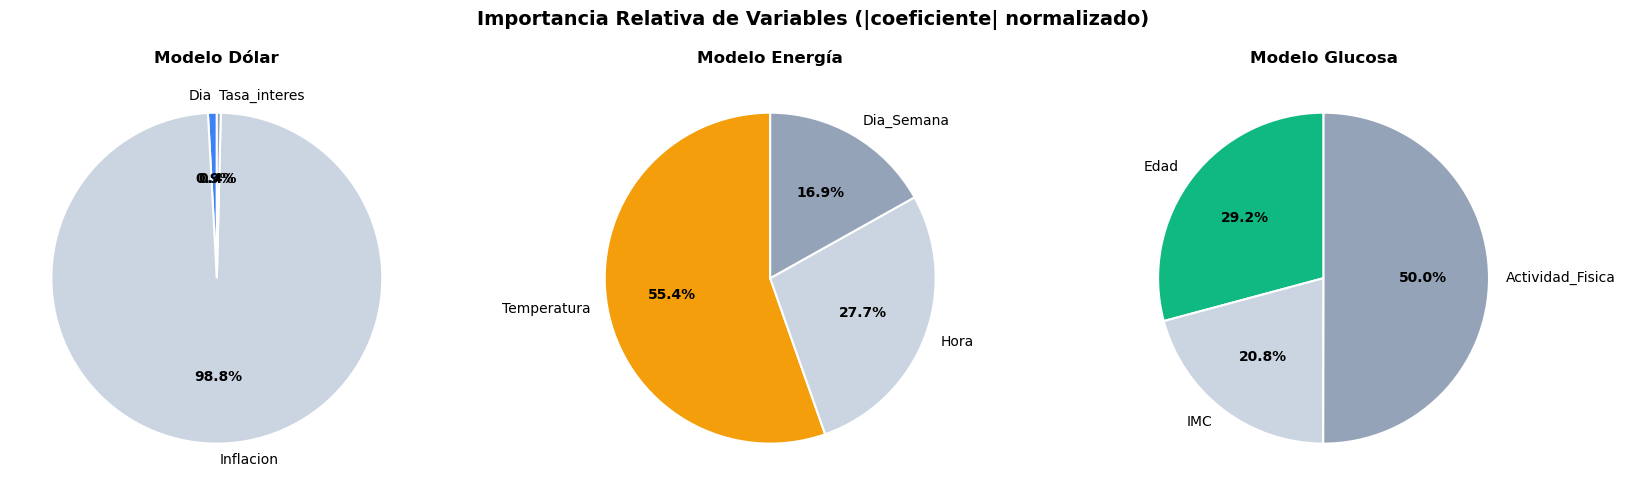

In [33]:
# Gráfica comparativa: importancia relativa de cada variable (|coef| normalizado)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Importancia Relativa de Variables (|coeficiente| normalizado)',
             fontsize=14, fontweight='bold')

colores_mod = {'Dólar': '#3b82f6', 'Energía': '#f59e0b', 'Glucosa': '#10b981'}

for ax, (nombre, m) in zip(axes, modelos.items()):
    abs_coefs = np.abs(m.coef_)
    norm_coefs = abs_coefs / abs_coefs.sum()
    feats = list(m.feature_names_in_)
    wedges, texts, autotexts = ax.pie(
        norm_coefs, labels=feats, autopct='%1.1f%%',
        colors=[colores_mod[nombre], '#cbd5e1', '#94a3b8'],
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5)
    )
    for t in autotexts:
        t.set_fontsize(10)
        t.set_fontweight('bold')
    ax.set_title(f'Modelo {nombre}', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()


In [34]:
# Función de predicción unificada
def predecir(modelo_nombre, **kwargs):
    """
    Predice usando cualquiera de los tres modelos.
    
    Ejemplos:
        predecir('Dólar',   Dia=10, Inflacion=6.0, Tasa_interes=8.0)
        predecir('Energía', Temperatura=30, Hora=14, Dia_Semana=1)
        predecir('Glucosa', Edad=50, IMC=29, Actividad_Fisica=2)
    """
    m = modelos[modelo_nombre]
    entrada = pd.DataFrame([kwargs])
    return round(m.predict(entrada)[0], 4)

# Ejemplos de uso
print("=== Predicciones con función unificada ===")
print(f"Dólar:   ${predecir('Dólar',   Dia=10, Inflacion=6.0, Tasa_interes=8.0):,.2f} COP")
print(f"Energía: {predecir('Energía', Temperatura=30, Hora=14, Dia_Semana=1):.2f} kWh")
print(f"Glucosa: {predecir('Glucosa', Edad=50, IMC=29, Actividad_Fisica=2):.2f} mg/dL")


=== Predicciones con función unificada ===
Dólar:   $577.82 COP
Energía: 467.06 kWh
Glucosa: 149.72 mg/dL


---
## ✅ Conclusiones

| Modelo | Variable de mayor impacto | Interpretación |
|--------|--------------------------|----------------|
| **Dólar** | `Inflacion` (−572.65) | Cada punto de inflación reduce la tasa de cambio en ~573 COP |
| **Energía** | `Temperatura` (+9.92) | Cada °C adicional incrementa el consumo en ~10 kWh |
| **Glucosa** | `Actividad_Fisica` (−2.09) | Cada hora de actividad semanal reduce la glucosa en ~2 mg/dL |

> Los modelos son de **regresión lineal simple** — útiles para tendencias generales, pero pueden requerir modelos más complejos para mayor precisión clínica o financiera.
